WQU Capstone project

The code below was used to develop the Capston Final Project.
Author name: Leon Galico
Group number: 6408
Topic: Call diagonal spread using deep ITM-LEAPS
Index
1. Pull data from CSV
2. Create dataframe and add cumulative QQQ returns
3. Black-Scholes calculations
4. Call price per month and per year
5. Dataframe filtering
6. Calculations for comparison between Call purchase and Owning shares

In [57]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.stats import norm

#1. Pull Data from CSV, Please copy the Datasource.csv file to the /content folder
# Get the current working directory
current_directory = os.getcwd()
print("Current Working Directory:", current_directory)

# List all files in the current directory
files = os.listdir(current_directory)
print("Files in Current Directory:", files)

# Provide the full path to the CSV file
file_path = 'DataSource.csv'  # Assuming the file is in the current directory

# Check if the file exists in the current directory
if file_path in files:
    # Load the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Create a new column for QQQ price including dividends
    df['QQQ Price with Dividends'] = df['QQQ'] + df['QQQ DIV']

    # Save the modified DataFrame back to a CSV file
    output_path = 'DataSource_with_Dividends.csv'
    df.to_csv(output_path, index=False)

    print(f"New column added and file saved as '{output_path}'")
else:
    print(f"File '{file_path}' not found in the current directory.")


Current Working Directory: /content
Files in Current Directory: ['.config', '.ipynb_checkpoints', 'DataSource.csv', 'DataSource_with_Dividends.csv', 'sample_data']
New column added and file saved as 'DataSource_with_Dividends.csv'


        Date       QQQ  QQQ DIV  CumDiv  QQQ WDiv
0  3/11/1999  51.43750      0.0     0.0  51.43750
1  3/12/1999  51.12500      0.0     0.0  51.12500
2  3/15/1999  50.43750      0.0     0.0  50.43750
3  3/16/1999  51.71875      0.0     0.0  51.71875
4  3/17/1999  51.93750      0.0     0.0  51.93750


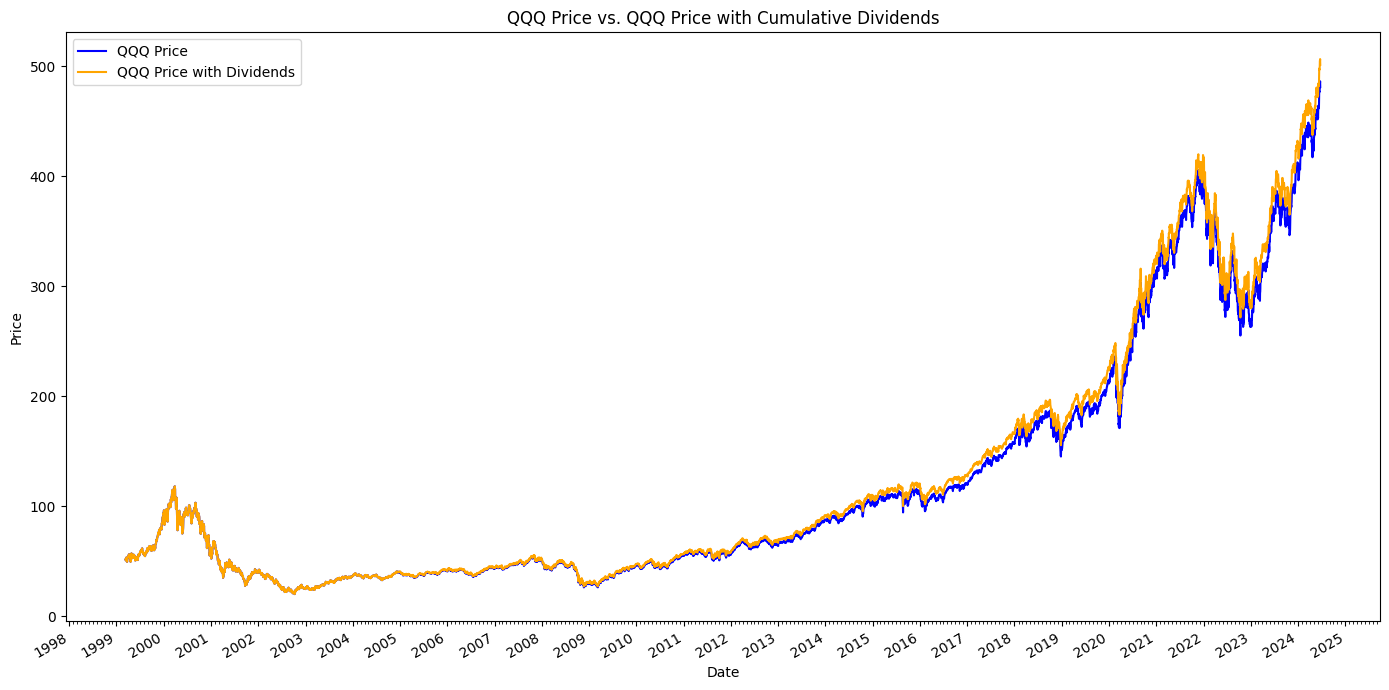

In [58]:
#2. Create dataframe and add cumulative QQQ returns

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Calculate the cumulative sum of dividends
df['CumDiv'] = df['QQQ DIV'].cumsum()

# Create a new column for QQQ price including cumulative dividends
df['QQQ WDiv'] = df['QQQ'] + df['CumDiv']

# Display the modified DataFrame or specific columns
print(df[['Date', 'QQQ', 'QQQ DIV', 'CumDiv', 'QQQ WDiv']].head())

# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Plot the trends
plt.figure(figsize=(14, 7))  # Increase figure size for better readability
plt.plot(df['Date'], df['QQQ'], label='QQQ Price', color='blue')
plt.plot(df['Date'], df['QQQ WDiv'], label='QQQ Price with Dividends', color='orange')

# Format x-axis with dates
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # Show one tick per year
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())  # Minor ticks for each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format ticks as 'Year'

# Rotate and format date labels
plt.gcf().autofmt_xdate()  # Auto format the date labels to fit well

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('QQQ Price vs. QQQ Price with Cumulative Dividends')
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


In [59]:
print(df.tail)

<bound method NDFrame.tail of            Date      Sigma  rate         QQQ  QQQ DIV  CumDiv    QQQ WDiv
0    1999-03-11  24.370001  4.77   51.437500      0.0   0.000   51.437500
1    1999-03-12  24.840000  4.76   51.125000      0.0   0.000   51.125000
2    1999-03-15  25.240000  4.76   50.437500      0.0   0.000   50.437500
3    1999-03-16  25.150000  4.74   51.718750      0.0   0.000   51.718750
4    1999-03-17  25.570000  4.74   51.937500      0.0   0.000   51.937500
...         ...        ...   ...         ...      ...     ...         ...
6592 2024-06-17  12.750000  5.11  479.459991      0.0  20.214  499.673991
6593 2024-06-18  12.300000  5.09  485.010010      0.0  20.214  505.224010
6594 2024-06-19  12.300000  5.09  485.010010      0.0  20.214  505.224010
6595 2024-06-20  13.280000  5.10  486.420013      0.0  20.214  506.634013
6596 2024-06-21  13.200000  5.10  481.190002      0.0  20.214  501.404002

[6597 rows x 7 columns]>


In [60]:

# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create a new column for the day of the week
df['DayOfWeek'] = df['Date'].dt.day_name()

# Filter rows for Mondays
dfm = df[df['DayOfWeek'] == 'Monday']

# If no rows for Monday, filter for Tuesdays
if dfm.empty:
    dfm = df[df['DayOfWeek'] == 'Tuesday']

# If no rows for Tuesday, filter for Wednesdays
if dfm.empty:
    dfm = df[df['DayOfWeek'] == 'Wednesday']

# Reset index for the new DataFrame
dfm = dfm.reset_index(drop=True)

# Print the resulting DataFrame
print(dfm)


           Date      Sigma  rate         QQQ  QQQ DIV  CumDiv    QQQ WDiv  \
0    1999-03-15  25.240000  4.76   50.437500      0.0   0.000   50.437500   
1    1999-03-22  25.000000  4.77   51.437500      0.0   0.000   51.437500   
2    1999-03-29  23.540001  4.75   52.375000      0.0   0.000   52.375000   
3    1999-04-05  22.190001  4.67   54.429688      0.0   0.000   54.429688   
4    1999-04-12  21.930000  4.66   54.500000      0.0   0.000   54.500000   
...         ...        ...   ...         ...      ...     ...         ...   
1314 2024-05-20  12.150000  5.15  451.980011      0.0  20.214  472.194011   
1315 2024-05-27  11.930000  5.21  455.290009      0.0  20.214  475.504009   
1316 2024-06-03  13.110000  5.14  454.570007      0.0  20.214  474.784007   
1317 2024-06-10  12.740000  5.16  461.820007      0.0  20.214  482.034007   
1318 2024-06-17  12.750000  5.11  479.459991      0.0  20.214  499.673991   

     DayOfWeek  
0       Monday  
1       Monday  
2       Monday  
3      

In [61]:
dfm=df
dfm = dfm.reset_index(drop=True)

In [62]:
#3.Black-Scholes calculations

def BS(sigma, rate, price, div, strike, T):
    # Calculate d1 and d2
    strk = strike * price

    # Handle division by zero
    if strk == 0:
        lns0 = 0  # or handle this case as needed
    else:
        lns0 = np.log(price / strk)

    con1 = (rate / 100 - div) + (sigma / 100)**2 / 2
    con2 = (sigma / 100) * np.sqrt(T)
    d1 = (lns0 + con1) / con2
    d2 = d1 - con2

    # Calculate the cumulative distribution functions for d1 and d2
    ndistd1 = norm.cdf(d1)
    ndistd2 = norm.cdf(d2)

    # Calculate the Black-Scholes price
    nexp = np.exp(-rate / 100 * T)
    callp = price * np.exp(-div * T) * ndistd1 - strk * nexp * ndistd2

    return callp

# Example usage
print(BS(24.84, 4.77, 51.125, 0.02, 0.2, 1))

40.36394002346132


In [63]:
#4. Call price per month and per year

dfm['Call Price Year'] = dfm.apply(
    lambda row: BS(row['Sigma'], row['rate'], row['QQQ'], 0.02, 0.2, 1),axis=1)
dfm['Call Price month'] = dfm.apply(
    lambda row: -BS(row['Sigma'], row['rate'], row['QQQ'], 0.02, 1.05, 30/252),axis=1)
print(dfm)

           Date      Sigma  rate         QQQ  QQQ DIV  CumDiv    QQQ WDiv  \
0    1999-03-11  24.370001  4.77   51.437500      0.0   0.000   51.437500   
1    1999-03-12  24.840000  4.76   51.125000      0.0   0.000   51.125000   
2    1999-03-15  25.240000  4.76   50.437500      0.0   0.000   50.437500   
3    1999-03-16  25.150000  4.74   51.718750      0.0   0.000   51.718750   
4    1999-03-17  25.570000  4.74   51.937500      0.0   0.000   51.937500   
...         ...        ...   ...         ...      ...     ...         ...   
6592 2024-06-17  12.750000  5.11  479.459991      0.0  20.214  499.673991   
6593 2024-06-18  12.300000  5.09  485.010010      0.0  20.214  505.224010   
6594 2024-06-19  12.300000  5.09  485.010010      0.0  20.214  505.224010   
6595 2024-06-20  13.280000  5.10  486.420013      0.0  20.214  506.634013   
6596 2024-06-21  13.200000  5.10  481.190002      0.0  20.214  501.404002   

      DayOfWeek  Call Price Year  Call Price month  
0      Thursday       

In [64]:

# Ensure the 'Date' column is in datetime format
dfm['Date'] = pd.to_datetime(dfm['Date'])

# Extract the year and create a helper column for grouping
dfm['Year'] = dfm['Date'].dt.year

# Group by the 'Year' column and get the first row of each group
df_first_of_year = dfm.groupby('Year').first().reset_index()

# Drop the helper column if you no longer need it
df_first_of_year = df_first_of_year.drop(columns='Year')

# Output the filtered DataFrame
print(df_first_of_year)



         Date      Sigma    rate         QQQ  QQQ DIV  CumDiv    QQQ WDiv  \
0  1999-03-11  24.370001  4.7700   51.437500      0.0   0.000   51.437500   
1  2000-01-03  24.209999  6.0900   96.187500      0.0   0.000   96.187500   
2  2001-01-01  26.850000  5.3200   61.562500      0.0   0.000   61.562500   
3  2002-01-01  23.799999  2.1700   40.310001      0.0   0.000   40.310001   
4  2003-01-01  28.620001  1.3200   24.540001      0.0   0.000   24.540001   
5  2004-01-01  18.309999  1.2600   36.619999      0.0   0.014   36.633999   
6  2005-01-03  14.080000  2.7900   40.090000      0.0   0.393   40.483000   
7  2006-01-02  12.070000  4.3800   40.540001      0.0   0.529   41.069001   
8  2007-01-01  11.560000  5.0000   43.189999      0.0   0.661   43.850999   
9  2008-01-01  22.500000  3.3400   51.570000      0.0   0.804   52.374000   
10 2009-01-01  40.000000  0.3700   29.459999      0.0   0.942   30.401999   
11 2010-01-01  21.680000  0.4700   46.259998      0.0   1.149   47.408998   

In [65]:

# Ensure the 'Date' column is in datetime format
dfm['Date'] = pd.to_datetime(dfm['Date'])

# Extract the year and create a helper column for grouping
dfm['Year'] = dfm['Date'].dt.year

# Group by the 'Year' column and get the first row of each group
df_first_of_year = dfm.groupby('Year').first().reset_index()

# Define the range
start_year = 1999
end_year = 2005

# Filter the DataFrame to include only the specified range
df_filtered_range = df_first_of_year[(df_first_of_year['Year'] >= start_year) & (df_first_of_year['Year'] <= end_year)]

# Drop the helper column if you no longer need it
df_filtered_range = df_filtered_range.drop(columns='Year')

# Output the filtered DataFrame
print(df_filtered_range)


        Date      Sigma  rate        QQQ  QQQ DIV  CumDiv   QQQ WDiv  \
0 1999-03-11  24.370001  4.77  51.437500      0.0   0.000  51.437500   
1 2000-01-03  24.209999  6.09  96.187500      0.0   0.000  96.187500   
2 2001-01-01  26.850000  5.32  61.562500      0.0   0.000  61.562500   
3 2002-01-01  23.799999  2.17  40.310001      0.0   0.000  40.310001   
4 2003-01-01  28.620001  1.32  24.540001      0.0   0.000  24.540001   
5 2004-01-01  18.309999  1.26  36.619999      0.0   0.014  36.633999   
6 2005-01-03  14.080000  2.79  40.090000      0.0   0.393  40.483000   

   DayOfWeek  Call Price Year  Call Price month  
0   Thursday        40.610663         -0.506157  
1     Monday        76.181963         -0.674222  
2     Monday        48.668887         -0.682952  
3    Tuesday        31.622870         -0.513203  
4  Wednesday        19.210436         -0.444403  
5   Thursday        28.662578         -0.284994  
6     Monday        31.498775         -0.139816  


In [66]:
df_filtered_range['Date'] = pd.to_datetime(df_filtered_range['Date'])

# Reset index to ensure it's sequential
df_filtered_range.reset_index(drop=True, inplace=True)

# Initialize the first row's Money Reserved as QQQ price minus call price
df_filtered_range.at[0, 'Money Reserved'] = df_filtered_range.at[0, 'QQQ'] - df_filtered_range.at[0, 'Call Price Year']
df_filtered_range.at[0, 'QQQ Appreciation'] = 0  # No appreciation for the first year
df_filtered_range.at[0, 'Balance'] = df_filtered_range.at[0, 'Money Reserved']

# Iterate over each year to calculate the reserved money, QQQ appreciation, and balance
for i in range(1, len(df_filtered_range)):
    # Get the previous year's Balance and current year's call price
    prev_balance = df_filtered_range.at[i-1, 'Balance']
    call_cost = df_filtered_range.at[i, 'Call Price Year']

    # Calculate the new money reserved
    reserved = prev_balance - call_cost

    # Calculate QQQ appreciation
    qqq_appreciation = df_filtered_range.at[i, 'QQQ'] - df_filtered_range.at[i-1, 'QQQ']

    # Calculate the balance based on appreciation
    if qqq_appreciation > 0:
        balance = reserved + qqq_appreciation
    else:
        balance = reserved

    # Update DataFrame
    df_filtered_range.at[i, 'Money Reserved'] = reserved
    df_filtered_range.at[i, 'QQQ Appreciation'] = qqq_appreciation
    df_filtered_range.at[i, 'Balance'] = balance

# Add a new column for Balance times rate / 100
df_filtered_range['Balance Times Rate'] = df_filtered_range['Balance'] * df_filtered_range['rate'] / 100

# Display the resulting DataFrame
print(df_filtered_range)

        Date      Sigma  rate        QQQ  QQQ DIV  CumDiv   QQQ WDiv  \
0 1999-03-11  24.370001  4.77  51.437500      0.0   0.000  51.437500   
1 2000-01-03  24.209999  6.09  96.187500      0.0   0.000  96.187500   
2 2001-01-01  26.850000  5.32  61.562500      0.0   0.000  61.562500   
3 2002-01-01  23.799999  2.17  40.310001      0.0   0.000  40.310001   
4 2003-01-01  28.620001  1.32  24.540001      0.0   0.000  24.540001   
5 2004-01-01  18.309999  1.26  36.619999      0.0   0.014  36.633999   
6 2005-01-03  14.080000  2.79  40.090000      0.0   0.393  40.483000   

   DayOfWeek  Call Price Year  Call Price month  Money Reserved  \
0   Thursday        40.610663         -0.506157       10.826837   
1     Monday        76.181963         -0.674222      -65.355126   
2     Monday        48.668887         -0.682952      -69.274013   
3    Tuesday        31.622870         -0.513203     -100.896883   
4  Wednesday        19.210436         -0.444403     -120.107320   
5   Thursday        2

In [67]:
# 6. Calculations for comparison between Call purchase and Owning shares
  # 6.1 QQQ Appreciation from the first to the last row
first_qqq = df_filtered_range.at[0, 'QQQ']
last_qqq = df_filtered_range.at[len(df_filtered_range)-1, 'QQQ']
qqq_appreciation = last_qqq - first_qqq

# 6.2. Sum of the "Balance Times Rate" column
balance_times_rate_sum = df_filtered_range['Balance Times Rate'].sum()

# 6.3. Final result calculation
first_call_price = df_filtered_range.at[0, 'Call Price Year']
last_balance = df_filtered_range.at[len(df_filtered_range)-1, 'Balance']
last_qqq_appreciation = df_filtered_range.at[len(df_filtered_range)-1, 'QQQ Appreciation']

final_result = first_call_price + balance_times_rate_sum + last_balance + last_qqq_appreciation

# Print results
print("QQQ Appreciation from first to last:", qqq_appreciation)
print("Sum of Balance Times Rate:", balance_times_rate_sum)
print("Final Result:", final_result)

QQQ Appreciation from first to last: -11.347499999999997
Sum of Balance Times Rate: -14.516612309752013
Final Result: -135.15462180053765


The following section is devoted to determining when
are good times to sell 1 month OTM calls with a 10%
POP (Probability of profit).

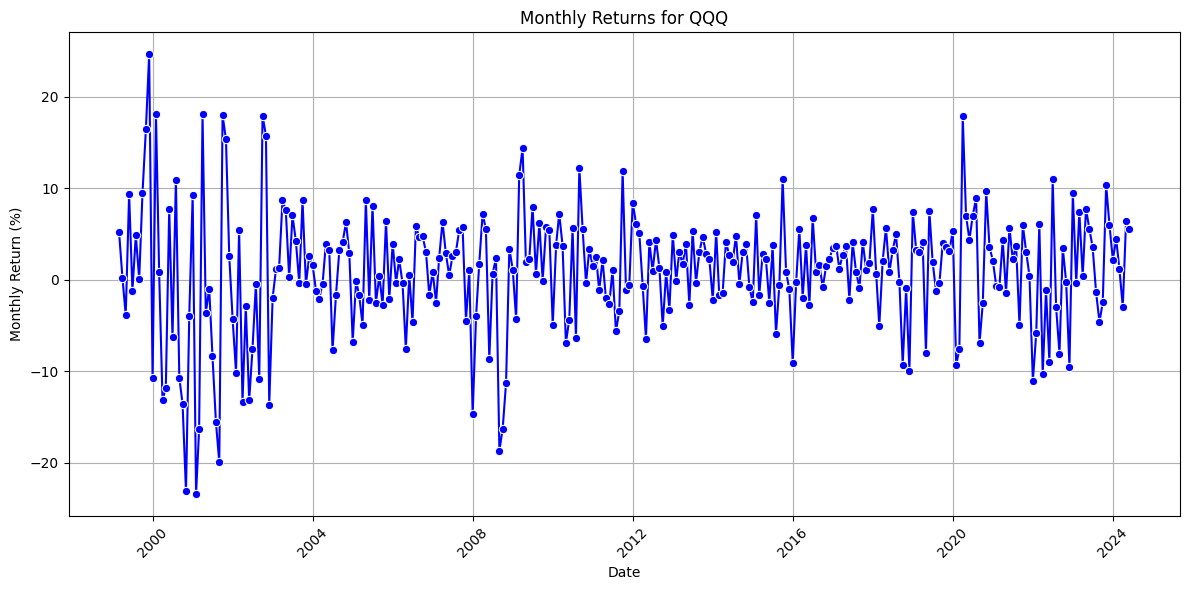

Monthly Returns DataFrame:
   Year  Month    first       last    Return       Date
0  1999      3  51.4375  54.125000  5.224787 1999-03-01
1  1999      4  54.0000  54.125000  0.231481 1999-04-01
2  1999      5  53.5625  51.500000 -3.850642 1999-05-01
3  1999      6  51.9375  56.804688  9.371240 1999-06-01
4  1999      7  57.8125  57.125000 -1.189189 1999-07-01


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Convert 'Date' column to datetime format if not already
df['Date'] = pd.to_datetime(df['Date'])

# Extract the month and year from the 'Date' column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Group by year and month, then calculate the monthly returns
monthly_returns = df.groupby(['Year', 'Month'])['QQQ WDiv'].agg(['first', 'last'])
monthly_returns['Return'] = ((monthly_returns['last'] - monthly_returns['first']) / monthly_returns['first']) * 100

# Reset index to make 'Year' and 'Month' columns
monthly_returns.reset_index(inplace=True)

# Create a datetime column for plotting
monthly_returns['Date'] = pd.to_datetime(monthly_returns[['Year', 'Month']].assign(day=1))

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_returns, x='Date', y='Return', marker='o', color='b')

plt.title('Monthly Returns for QQQ')
plt.ylabel('Monthly Return (%)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

print("Monthly Returns DataFrame:")
print(monthly_returns.head())


<ipython-input-75-5e9ac2ab4732>:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prob_df, x='Month', y='Probability', palette='viridis', hue=None, legend=False)


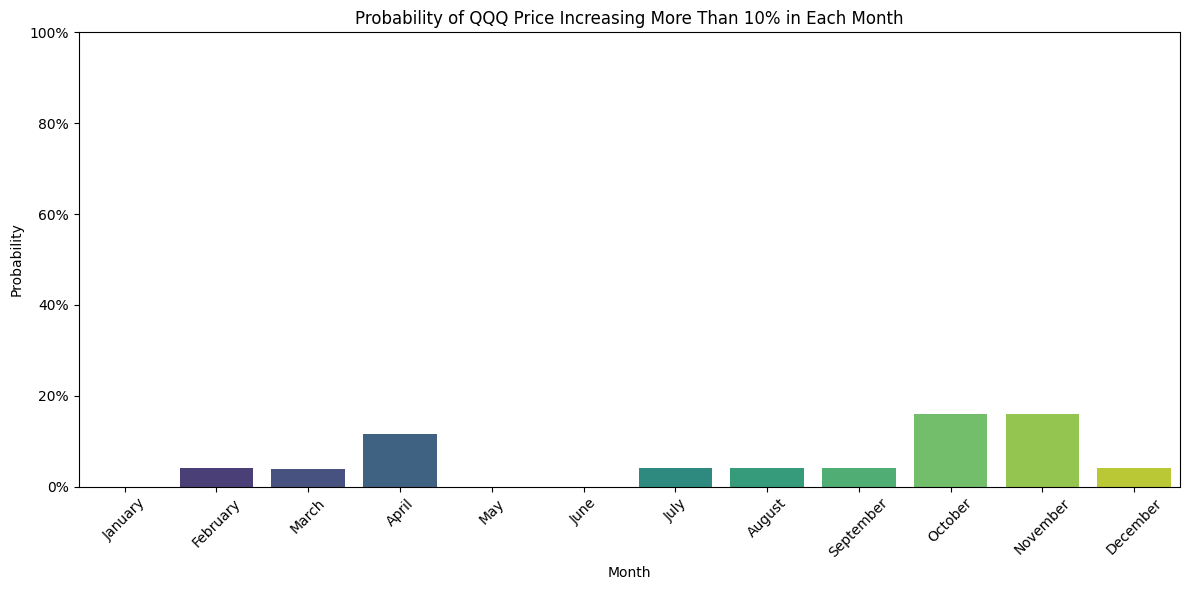

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Date' column to datetime format if not already
df['Date'] = pd.to_datetime(df['Date'])

# Extract the month and year from the 'Date' column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Initialize a dictionary to store probabilities
probabilities = {}

# Loop through each month (1 for January, 12 for December)
for month in range(1, 13):
    # Filter data for the specific month across all years
    monthly_data = df[df['Month'] == month]

    # Group by year to get data for each month in each year
    grouped = monthly_data.groupby('Year')

    # Initialize counters
    total_months = 0
    months_with_10p_increase = 0

    for year, group in grouped:
        # Ensure the group has more than one day to compute change
        if len(group) > 1:
            # Sort the group by date
            group_sorted = group.sort_values('Date')

            # Get the price at the beginning and end of the month
            start_price = group_sorted['QQQ WDiv'].iloc[0]
            end_price = group_sorted['QQQ WDiv'].iloc[-1]

            # Calculate percentage change only if start_price is not zero
            if pd.notna(start_price) and start_price != 0:
                pct_change = ((end_price - start_price) / start_price) * 100

                # Update counters
                total_months += 1
                if pct_change > 10:
                    months_with_10p_increase += 1

    # Calculate probability
    if total_months > 0:
        probability = months_with_10p_increase / total_months
    else:
        probability = None  # Handle months with no data

    # Store the probability with month name
    probabilities[pd.to_datetime(f'2023-{month}-01').strftime('%B')] = probability

# Convert the probabilities dictionary to a DataFrame for visualization
prob_df = pd.DataFrame.from_dict(probabilities, orient='index', columns=['Probability'])
prob_df.reset_index(inplace=True)
prob_df.rename(columns={'index': 'Month'}, inplace=True)

# Drop months with None probability (if any)
prob_df.dropna(inplace=True)

# Sort the DataFrame by month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
prob_df['Month'] = pd.Categorical(prob_df['Month'], categories=month_order, ordered=True)
prob_df.sort_values('Month', inplace=True)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=prob_df, x='Month', y='Probability', palette='viridis', hue=None, legend=False)

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.title('Probability of QQQ Price Increasing More Than 10% in Each Month')
plt.ylabel('Probability')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Since probability ranges from 0 to 1

plt.tight_layout()
plt.show()


In [82]:

df = df.reset_index(drop=True)
df.tail()

,Date,Sigma,rate,QQQ,QQQ DIV,CumDiv,QQQ WDiv,DayOfWeek,Month,Year
6592,2024-06-17,12.75,5.11,479.459991,0.0,20.214,499.673991,Monday,6,2024
6593,2024-06-18,12.30,5.09,485.010010,0.0,20.214,505.224010,Tuesday,6,2024
6594,2024-06-19,12.30,5.09,485.010010,0.0,20.214,505.224010,Wednesday,6,2024
6595,2024-06-20,13.28,5.10,486.420013,0.0,20.214,506.634013,Thursday,6,2024
6596,2024-06-21,13.20,5.10,481.190002,0.0,20.214,501.404002,Friday,6,2024


Percentage Returns Table:
  Date of Interest Start of Next Month End of Next Month  Percentage Change
0       2000-02-02          2000-03-01        2000-03-31           0.830420
1       2004-06-30          2004-07-01        2004-07-30          -7.697622
2       2015-12-16          2016-01-01        2016-01-29          -9.140233
3       2018-12-19          2019-01-01        2019-01-31           7.420529
4       2022-03-16          2022-04-01        2022-04-29         -10.340703
5       2023-07-26          2023-08-01        2023-08-31          -1.341188


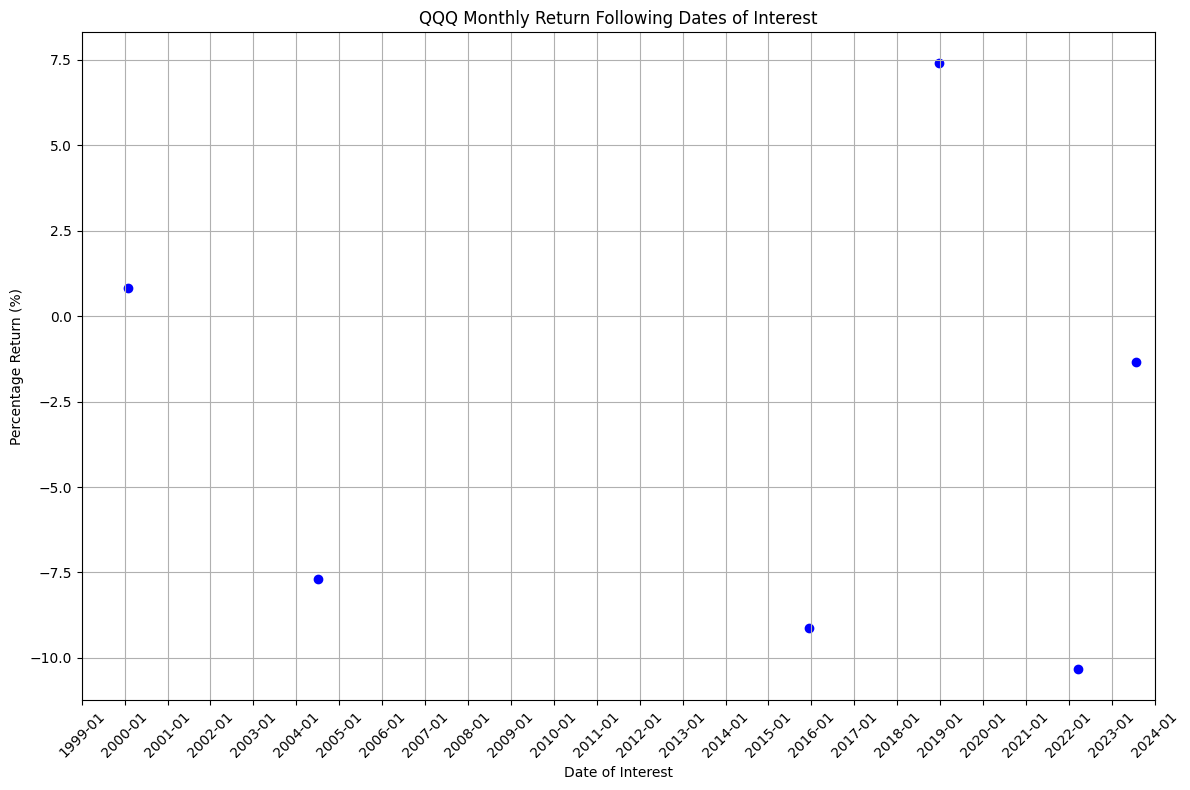

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def calculate_and_plot_returns(dates_of_interest):
    # Ensure the 'Date' column in df is in datetime format
    df['Date'] = pd.to_datetime(df.iloc[:, 0])

    # Convert the dates_of_interest to datetime format
    dates_of_interest = pd.to_datetime(dates_of_interest)

    # Create an empty list to store the results
    results = []

    # Loop through each date of interest
    for date in dates_of_interest:
        # Find the start and end dates of the month following the date of interest
        start_next_month = (date + pd.DateOffset(months=1)).replace(day=1)
        end_next_month = (start_next_month + pd.DateOffset(months=1)) - pd.DateOffset(days=1)

        # Find the closest available date if data is missing
        start_row = df[df['Date'] >= start_next_month].iloc[0:1]
        end_row = df[df['Date'] <= end_next_month].iloc[-1:]

        # If no data was found for the start date, use the closest available date
        if start_row.empty:
            start_row = df[df['Date'] >= start_next_month].iloc[0:1]
        if end_row.empty:
            end_row = df[df['Date'] <= end_next_month].iloc[-1:]

        if not start_row.empty and not end_row.empty:
            # Calculate the percentage change
            start_price = start_row['QQQ WDiv'].values[0]
            end_price = end_row['QQQ WDiv'].values[0]
            pct_change = (end_price - start_price) / start_price * 100

            # Store the result as a dictionary
            results.append({
                'Date of Interest': date,
                'Start of Next Month': start_row['Date'].values[0],
                'End of Next Month': end_row['Date'].values[0],
                'Percentage Change': pct_change
            })
        else:
            print(f"No data available for dates: Start - {start_next_month}, End - {end_next_month}")

    # Convert results to a DataFrame for easy display and plotting
    results_df = pd.DataFrame(results)

    # Reset index if necessary
    results_df.reset_index(drop=True, inplace=True)

    # Display the results in a table
    print("Percentage Returns Table:")
    print(results_df)

    # Plotting the results with only dots, no lines
    plt.figure(figsize=(12, 8))
    plt.scatter(results_df['Date of Interest'], results_df['Percentage Change'], color='b')
    plt.title('QQQ Monthly Return Following Dates of Interest')
    plt.xlabel('Date of Interest')
    plt.ylabel('Percentage Return (%)')
    plt.grid(True)

    # Set x-axis limits from the lowest date to 2024-01-01
    plt.xlim(pd.to_datetime('1999-01-01'), pd.to_datetime('2024-01-01'))

    # Format x-axis ticks to display fewer dates
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator())  # Change to YearLocator to show one tick per year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as Year-Month

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage:
dates_of_interest = ['2000-02-02', '2004-06-30', '2015-12-16', '2018-12-19', '2022-03-16', '2023-07-26']
calculate_and_plot_returns(dates_of_interest)


Percentage Returns Table:
  Date of Interest Start of Next Month End of Next Month  Percentage Change
0       2000-11-07          2000-12-01        2000-12-29          -3.902439
1       2004-11-02          2004-12-01        2004-12-31           2.899397
2       2008-11-04          2008-12-01        2008-12-31           3.411677
3       2012-11-06          2012-12-03        2012-12-31          -3.242057
4       2016-11-08          2016-12-01        2016-12-30           2.272693
5       2020-11-03          2020-12-01        2020-12-31           3.642088


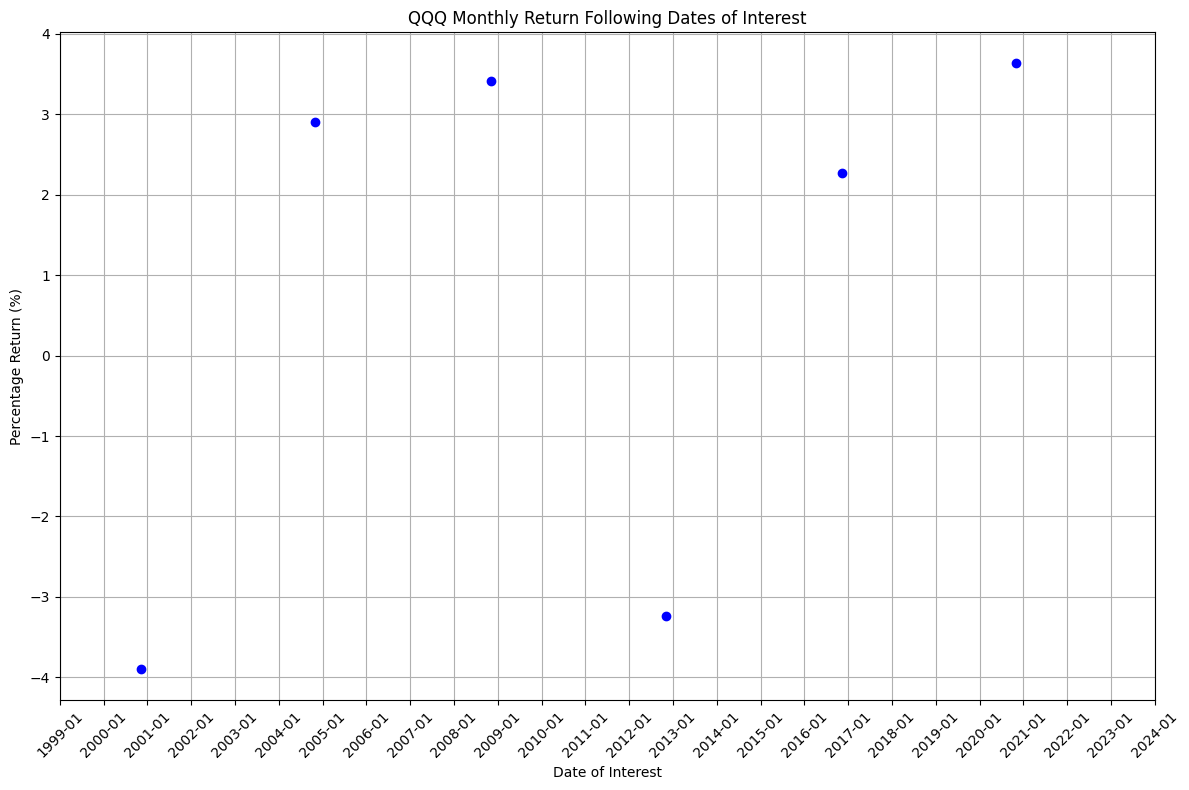

In [92]:
#presidential_election_dates

dates_of_interest = ['2000-11-07', '2004-11-02', '2008-11-04', '2012-11-06', '2016-11-08', '2020-11-03']
calculate_and_plot_returns(dates_of_interest)

Percentage Returns Table:
    Date of Interest Start of Next Month End of Next Month  Percentage Change
0         2000-01-03          2000-02-01        2000-02-29          18.115183
1         2000-03-22          2000-04-03        2000-04-28         -13.179643
2         2000-05-16          2000-06-01        2000-06-30           7.776963
3         2000-06-28          2000-07-03        2000-07-31          -6.283422
4         2000-08-22          2000-09-01        2000-09-29         -10.679612
..               ...                 ...               ...                ...
165       2023-05-03          2023-06-01        2023-06-30           5.563533
166       2023-06-14          2023-07-03        2023-07-31           3.534707
167       2023-07-26          2023-08-01        2023-08-31          -1.341188
168       2023-09-20          2023-10-02        2023-10-31          -2.468467
169       2023-11-01          2023-12-01        2023-12-29           6.042321

[170 rows x 4 columns]


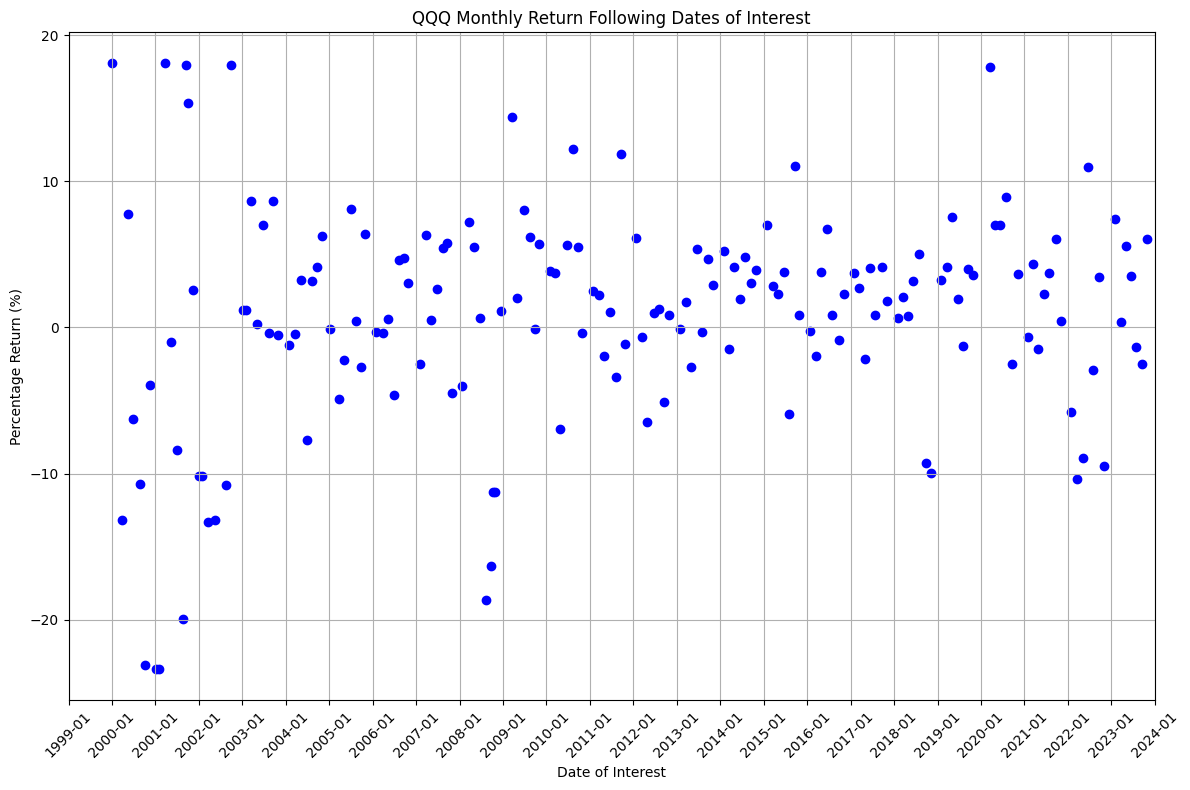

In [94]:
#Fed Interest rate changes



dates_of_interest = [
    '2000-01-03', '2000-03-22', '2000-05-16', '2000-06-28', '2000-08-22', '2000-10-05', '2000-11-15',
    '2001-01-03', '2001-01-31', '2001-03-20', '2001-05-15', '2001-06-27', '2001-08-22', '2001-09-17',
    '2001-10-03', '2001-11-15', '2002-01-03', '2002-01-30', '2002-03-20', '2002-05-15', '2002-08-14',
    '2002-09-24', '2003-01-03', '2003-01-30', '2003-03-19', '2003-05-06', '2003-06-26', '2003-08-12',
    '2003-09-17', '2003-10-29', '2004-01-29', '2004-03-17', '2004-05-06', '2004-06-30', '2004-08-12',
    '2004-09-22', '2004-10-28', '2005-01-05', '2005-03-23', '2005-05-06', '2005-06-30', '2005-08-10',
    '2005-09-21', '2005-10-27', '2006-01-31', '2006-03-28', '2006-05-10', '2006-06-28', '2006-08-09',
    '2006-09-20', '2006-10-25', '2007-01-31', '2007-03-21', '2007-05-09', '2007-06-28', '2007-08-17',
    '2007-09-18', '2007-10-31', '2008-01-22', '2008-03-18', '2008-04-30', '2008-06-25', '2008-08-13',
    '2008-09-18', '2008-10-08', '2008-10-29', '2008-12-16', '2009-03-18', '2009-04-29', '2009-06-24',
    '2009-08-12', '2009-09-23', '2009-10-28', '2010-01-27', '2010-03-16', '2010-04-28', '2010-06-23',
    '2010-08-10', '2010-09-22', '2010-10-27', '2011-01-26', '2011-03-16', '2011-04-27', '2011-06-22',
    '2011-08-09', '2011-09-21', '2011-10-26', '2012-01-25', '2012-03-13', '2012-04-25', '2012-06-20',
    '2012-08-01', '2012-09-13', '2012-10-24', '2013-01-30', '2013-03-20', '2013-05-01', '2013-06-19',
    '2013-07-31', '2013-09-18', '2013-10-30', '2014-01-29', '2014-03-19', '2014-04-30', '2014-06-18',
    '2014-07-30', '2014-09-17', '2014-10-29', '2015-01-28', '2015-03-18', '2015-04-29', '2015-06-17',
    '2015-07-29', '2015-09-17', '2015-10-28', '2016-01-27', '2016-03-16', '2016-04-27', '2016-06-15',
    '2016-07-27', '2016-09-21', '2016-11-02', '2017-01-31', '2017-03-15', '2017-05-03', '2017-06-14',
    '2017-07-26', '2017-09-20', '2017-11-01', '2018-01-31', '2018-03-21', '2018-05-02', '2018-06-13',
    '2018-07-31', '2018-09-26', '2018-11-08', '2019-01-30', '2019-03-20', '2019-05-01', '2019-06-19',
    '2019-07-31', '2019-09-18', '2019-10-30', '2020-03-15', '2020-04-29', '2020-06-10', '2020-07-29',
    '2020-09-16', '2020-11-05', '2021-01-27', '2021-03-17', '2021-04-28', '2021-06-16', '2021-07-28',
    '2021-09-22', '2021-11-03', '2022-01-26', '2022-03-16', '2022-05-04', '2022-06-15', '2022-07-27',
    '2022-09-21', '2022-11-02', '2023-02-01', '2023-03-22', '2023-05-03', '2023-06-14', '2023-07-26',
    '2023-09-20', '2023-11-01'
]
calculate_and_plot_returns(dates_of_interest)